In [1]:
import pandas as pd

In [2]:
df1=pd.read_csv('data/final/global_shap_values.csv')
df1=df1[[ 'PID','lon', 'lat','shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness', 'shap_Shannon Diversity', 'shap_Simpson\'s Index', 'shap_Species Richness']]

In [4]:
fd_df = pd.read_csv('data/final/final_dataset.csv')


# fd_df=fd_df[['PID', 'WSCI','Annual Temp', 'Annual Precipitation', 'Precipitation Seasonality',]]
fd_df["WSCI_group"] = pd.qcut(fd_df["WSCI"], q=6, labels=["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"])

In [5]:
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')
fd_df=fd_df.merge(PID_df[['PID', 'biome', 'lon', 'lat']], on='PID', how='left')


In [19]:
# Identify the feature columns (everything except PID)
feature_cols = ['shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness',]

# Find the column name with the largest SHAP value for each row
top_feature_df = pd.DataFrame({
    'PID': df1['PID'],
    'top_feature': df1[feature_cols].idxmax(axis=1),
    'lon': df1['lon'],
    'lat': df1['lat']
})


In [20]:
df2=top_feature_df.merge(fd_df, on='PID', how='left')

In [21]:
# df2=df1.merge(fd_df, on='PID', how='left')

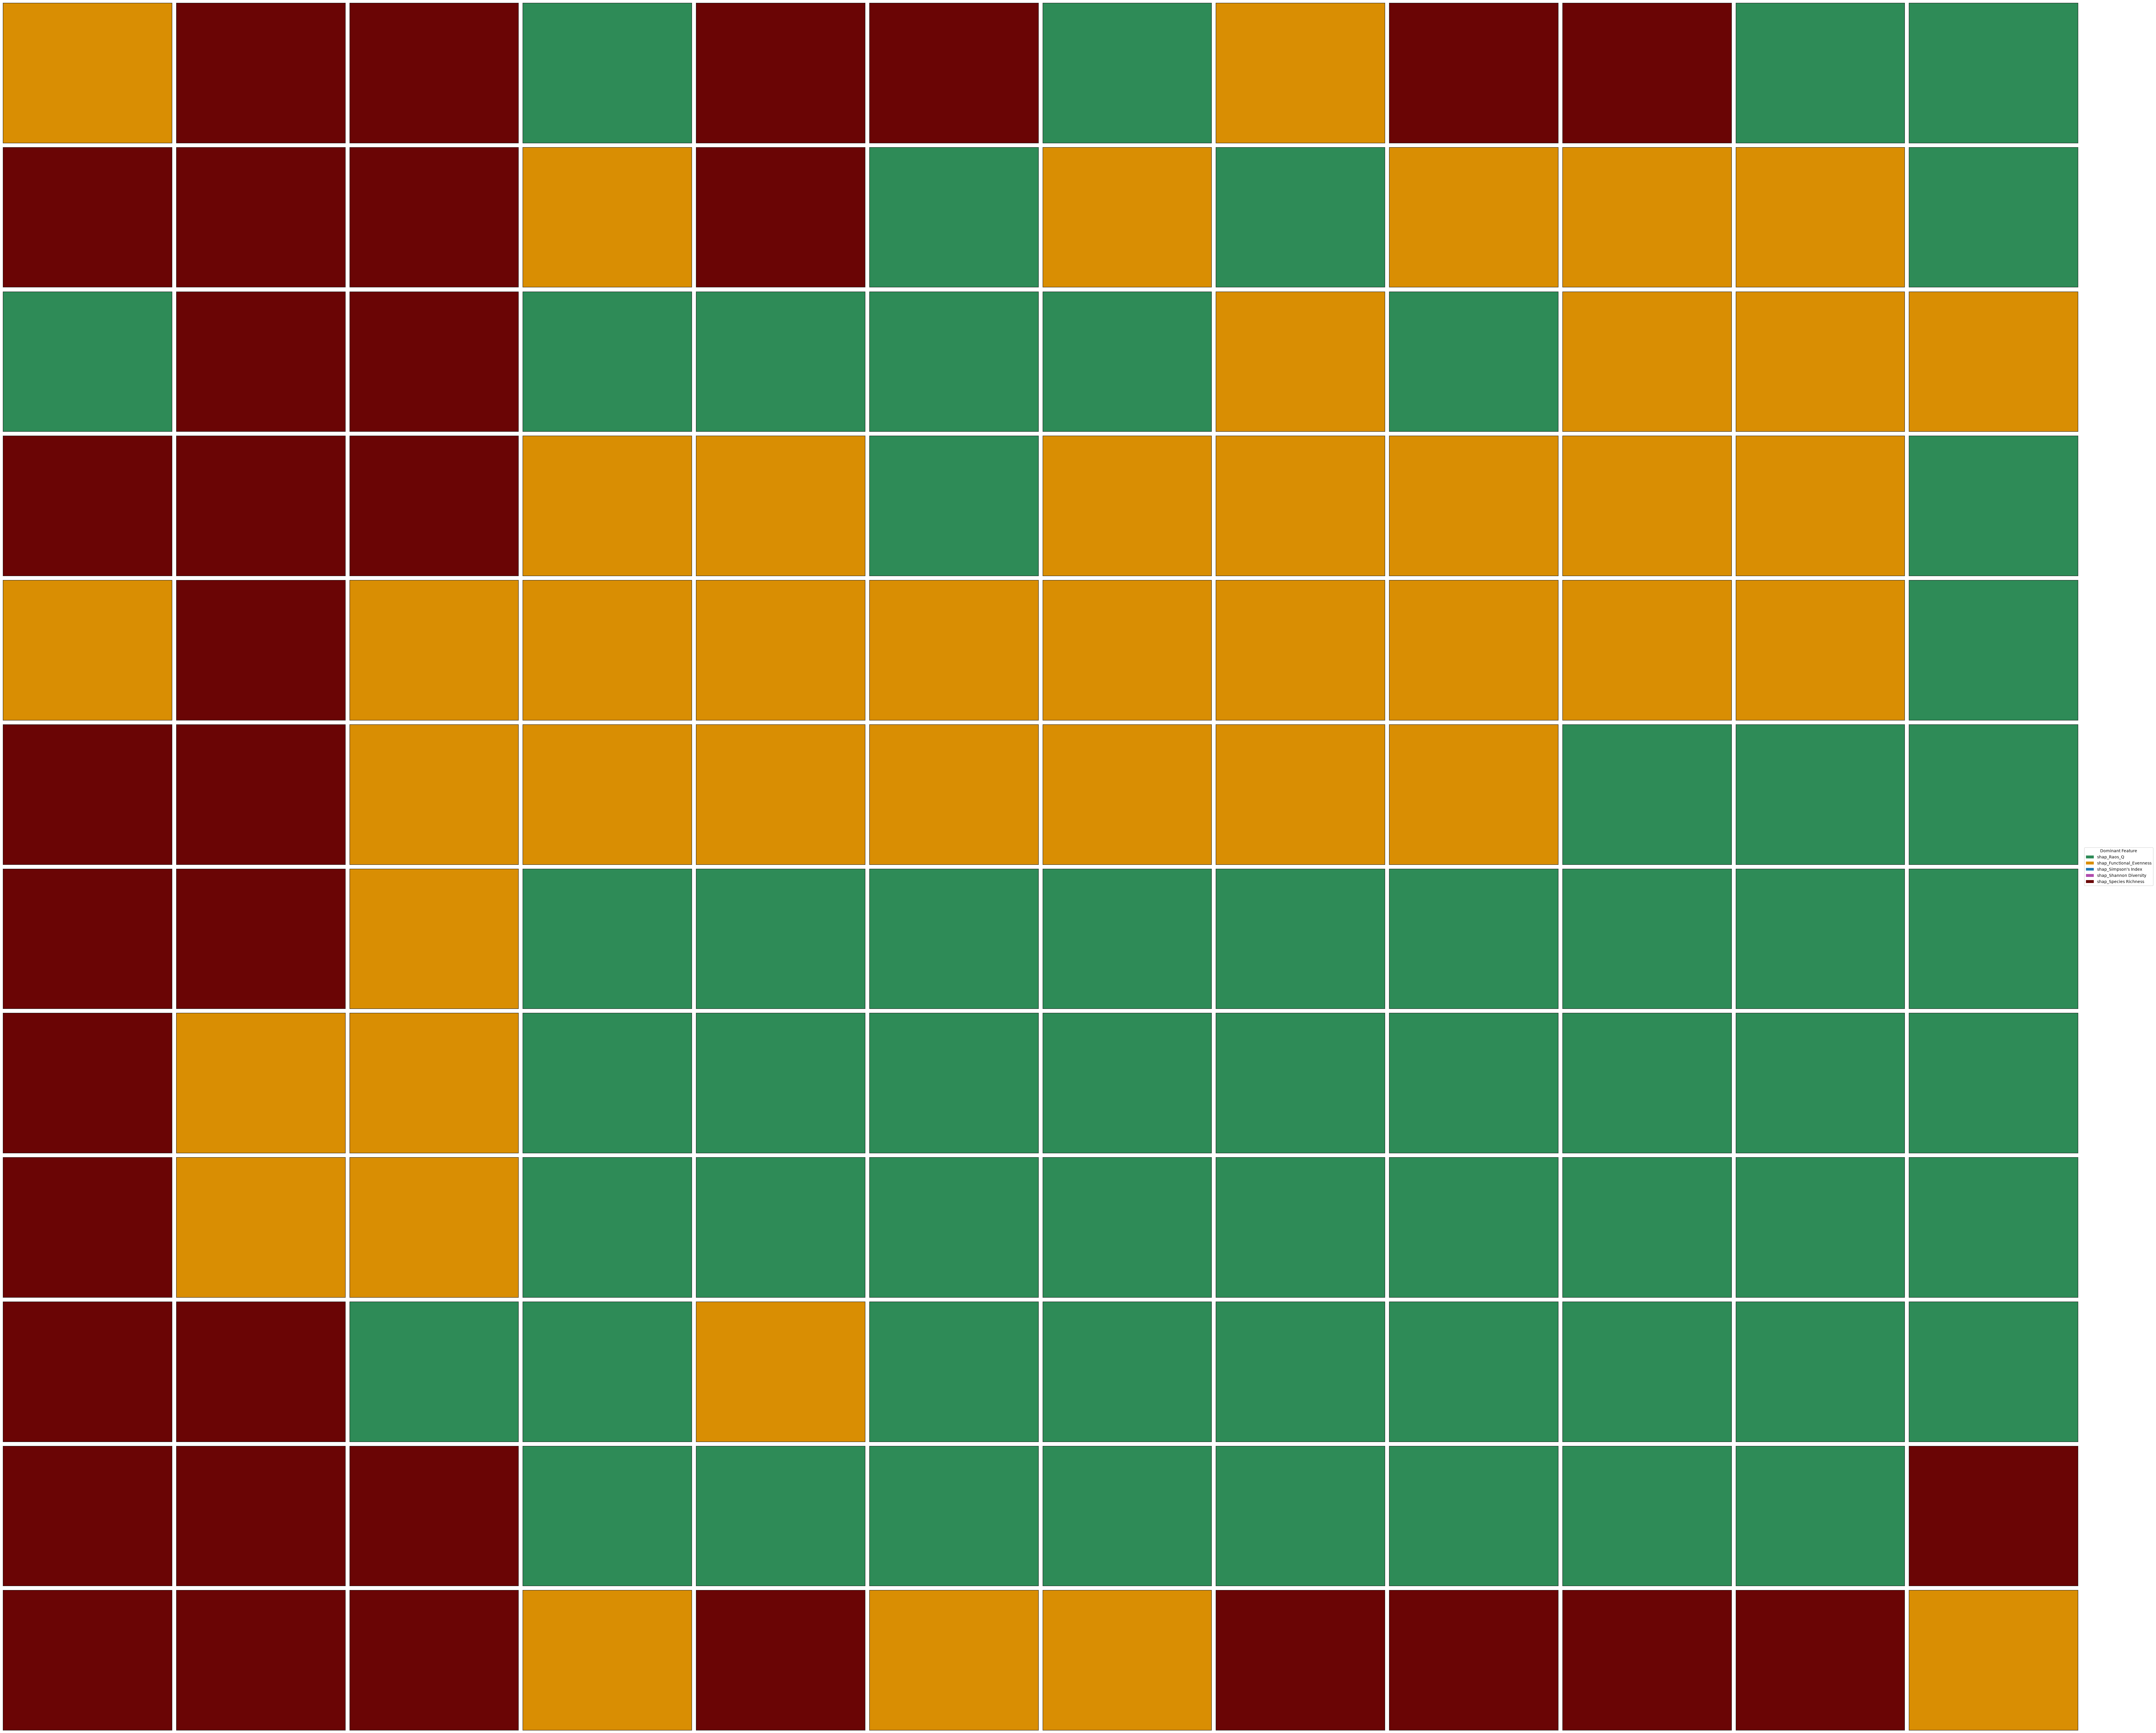

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import pandas as pd
import itertools
import numpy as np 

n_precip=12
n_temp=12
# --- Tertile splits for Temp and Precip (Low/Medium/High) ---
df2["Temp_group"] = pd.qcut(df2["Annual Temp"], q=n_temp, labels=np.arange(1, n_temp + 1))  # 1 = Low, 5 = High
df2["Precip_group"] = pd.qcut(df2["Annual Precipitation"], q=n_precip, labels=np.arange(1, n_precip + 1))  # 1 = Low, 5 = High

# --- Generate all 25 combinations, Temp ordered High -> Low ---
temp_levels_ordered =np.arange(1, n_temp + 1)[::-1]
precip_levels_ordered = np.arange(1, n_precip + 1)  # left to right, unchanged

groups = {}
for temp_lvl, precip_lvl in itertools.product(temp_levels_ordered, precip_levels_ordered):
    name = f"Temp_{temp_lvl}_Precip_{precip_lvl}"
    groups[name] = df2[
        (df2["Temp_group"] == temp_lvl) &
        (df2["Precip_group"] == precip_lvl)
    ]


color_map = {
    # Functional Diversity (FD) - Shades of Green
    "shap_Raos_Q": "#2E8B57",               # SeaGreen
    "shap_Functional_Evenness": "#D98E03",  # Orange
    # Species Diversity (SD) - Shades of Blue
    "shap_Simpson's Index": "#1F77B4",      # Medium Blue
    "shap_Shannon Diversity": "#B04CAE",    # Purple/Magenta
    "shap_Species Richness": "#6A0505",     # Dark Red
}
# biome_colors = {
#     'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
#     'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
#     'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
#     'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
#     'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
#     'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
#     'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
#     'NaN':                          '#D3D3D3'    # Light Gray
# }

# color_map=biome_colors
n = len(groups)
ncols = n_temp
nrows = n_precip

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, (name, df) in enumerate(groups.items()):
    ax = axes[i]

    if df.empty:
        ax.set_title(f"{name} (no data)")
        ax.axis('off')
        continue

    # Find the most common dominant feature in this group
    mode_feature = df['top_feature'].mode()
    if mode_feature.empty:
        ax.set_title(f"{name} (no data)")
        ax.axis('off')
        continue

    mode_feature = mode_feature.iloc[0]
    fill_color = color_map.get(mode_feature, "#D3D3D3")  # gray fallback if unmapped

    # Fill entire panel with that color
    ax.set_facecolor(fill_color)
    ax.set_xticks([])
    ax.set_yticks([])

    n_matching = (df['top_feature'] == mode_feature).sum()

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

# Shared legend
legend_elements = [Patch(facecolor=color, label=feat) for feat, color in color_map.items()]
fig.legend(
    handles=legend_elements,
    title="Dominant Feature",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

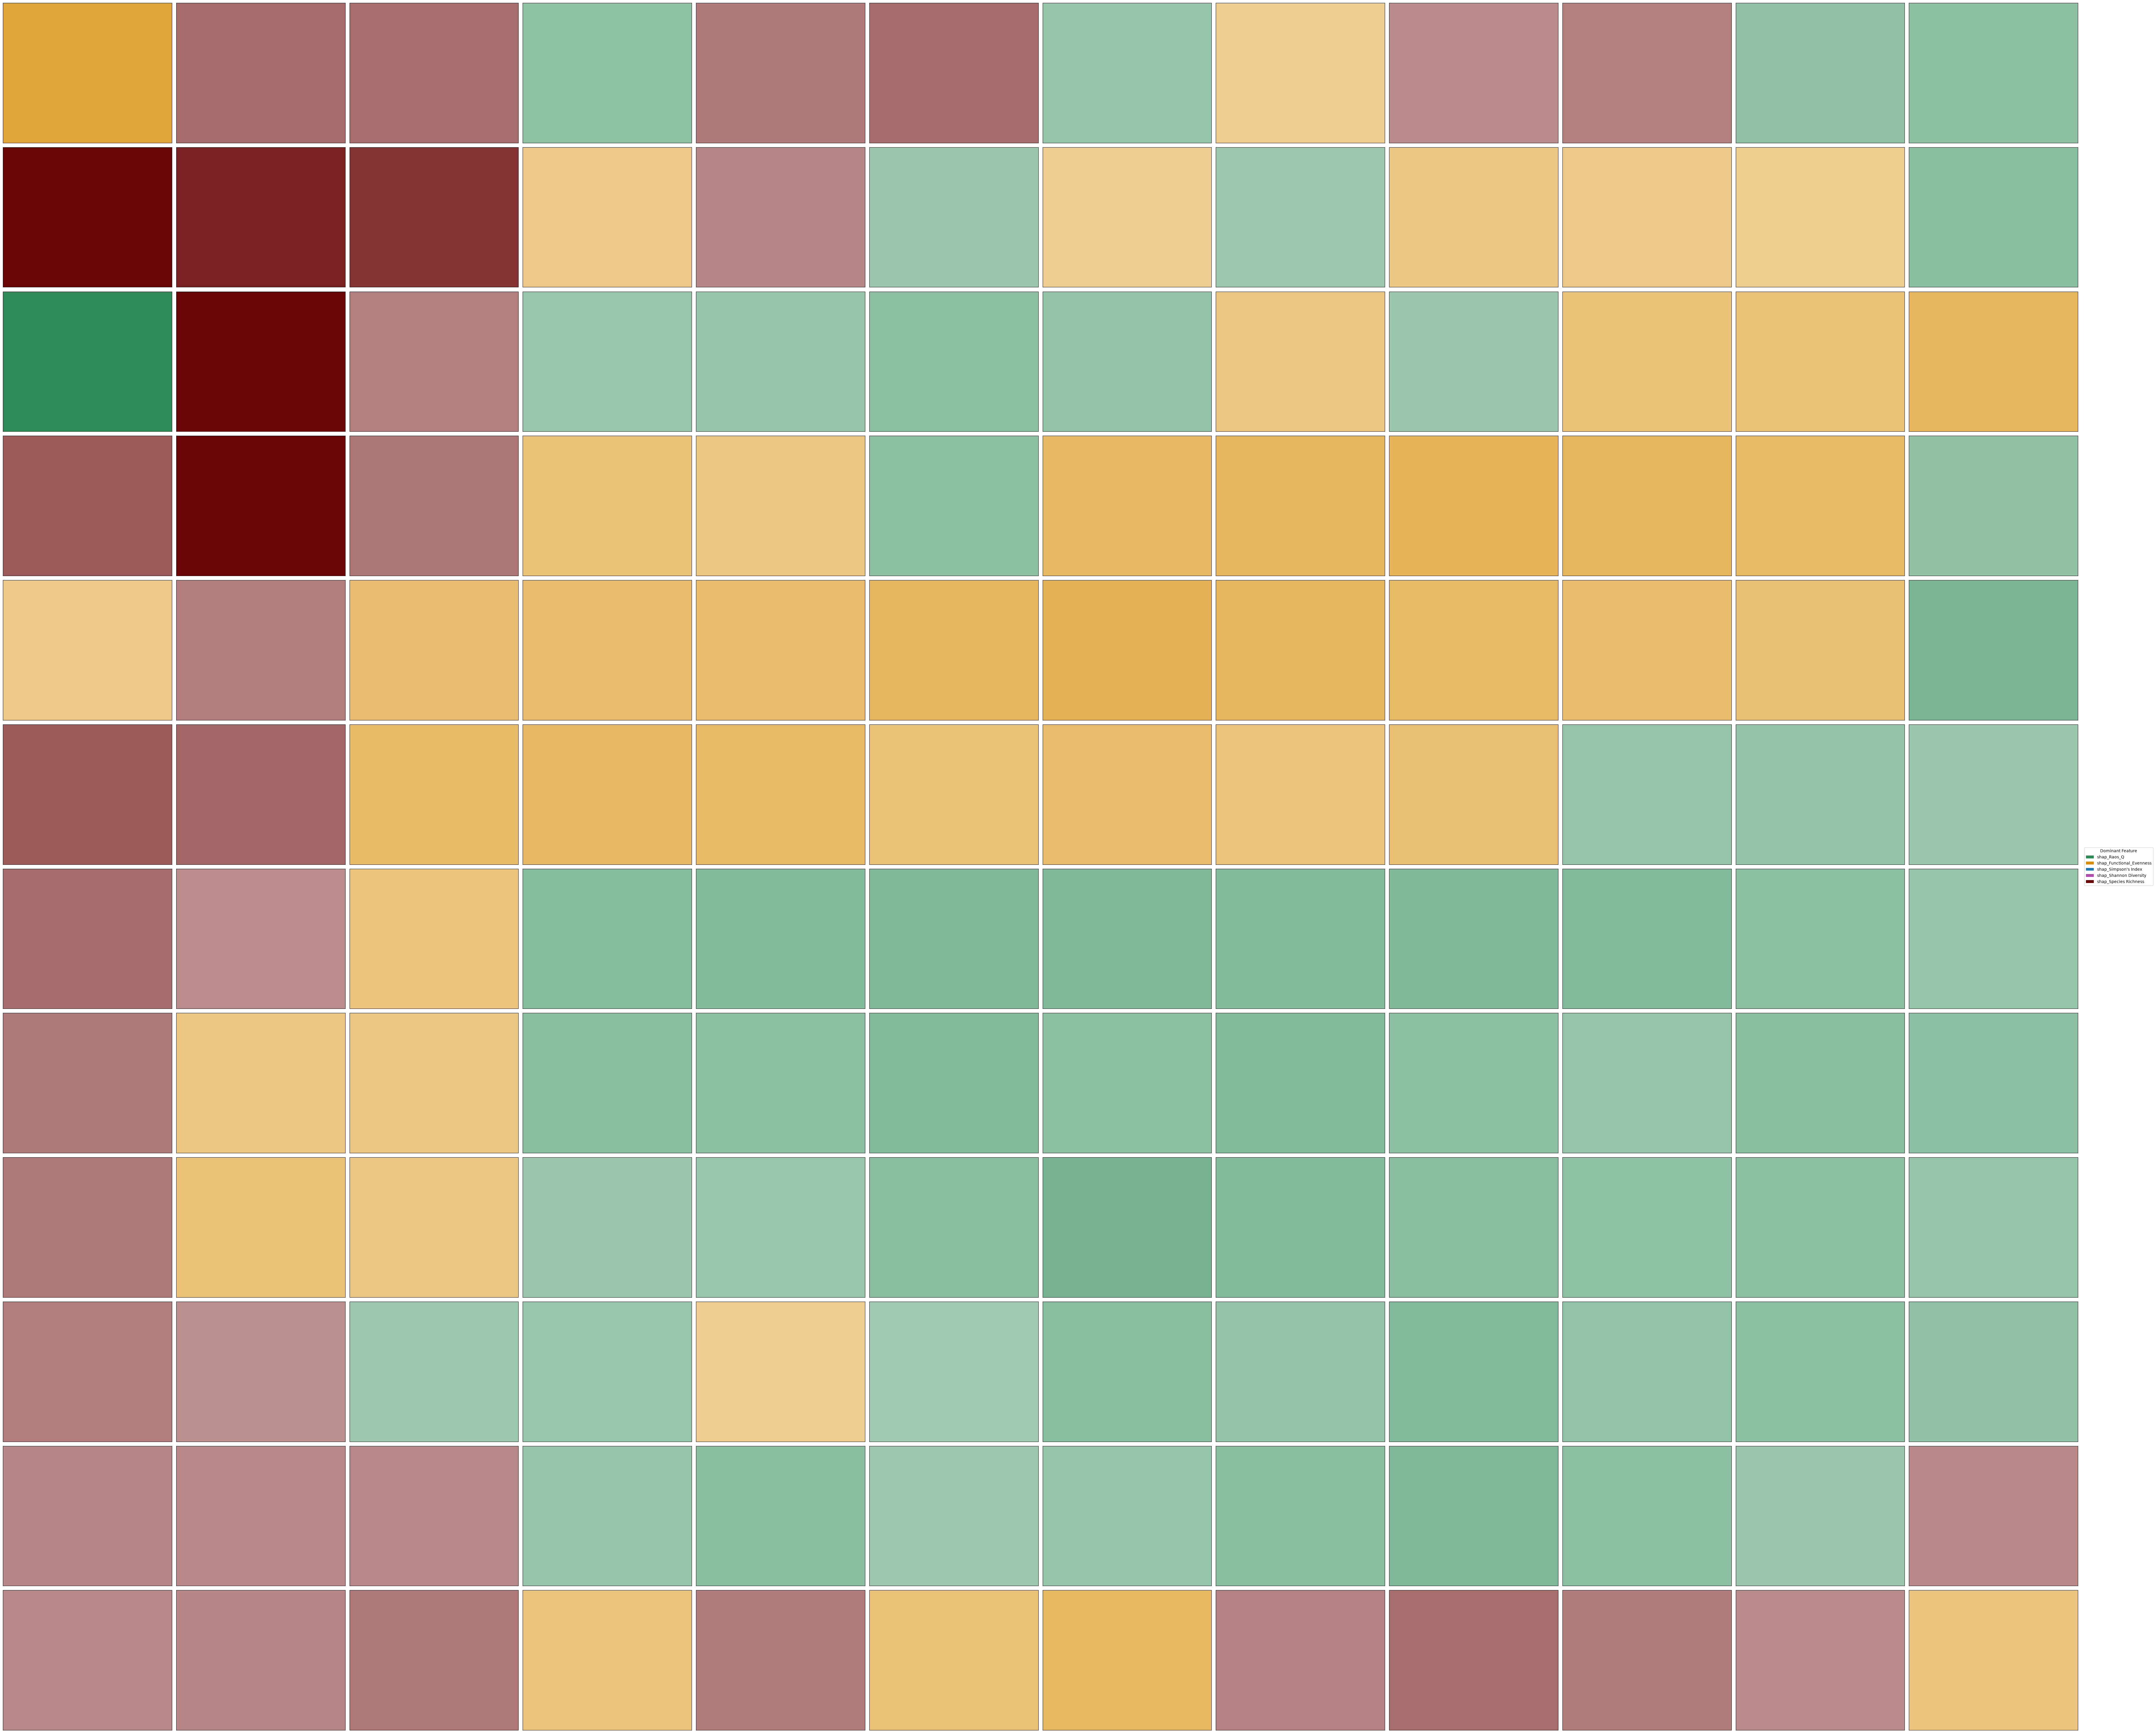

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb

import pandas as pd
import itertools
import numpy as np

n_precip = 12
n_temp = 12

# --- Tertile splits for Temp and Precip (Low/Medium/High) ---
df2["Temp_group"] = pd.qcut(df2["Annual Temp"], q=n_temp, labels=np.arange(1, n_temp + 1))
df2["Precip_group"] = pd.qcut(df2["Annual Precipitation"], q=n_precip, labels=np.arange(1, n_precip + 1))

# --- Generate all combinations, Temp ordered High -> Low ---
temp_levels_ordered = np.arange(1, n_temp + 1)[::-1]
precip_levels_ordered = np.arange(1, n_precip + 1)

groups = {}
for temp_lvl, precip_lvl in itertools.product(temp_levels_ordered, precip_levels_ordered):
    name = f"Temp_{temp_lvl}_Precip_{precip_lvl}"
    groups[name] = df2[
        (df2["Temp_group"] == temp_lvl) &
        (df2["Precip_group"] == precip_lvl)
    ]

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}

# --- alpha settings ---
MIN_ALPHA = 0.15   # floor so low-dominance panels aren't invisible
MAX_ALPHA = 1.0

n = len(groups)
ncols = n_temp
nrows = n_precip

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, (name, df) in enumerate(groups.items()):
    ax = axes[i]

    if df.empty:
        ax.set_title(f"{name} (no data)")
        ax.axis('off')
        continue

    mode_feature = df['top_feature'].mode()
    if mode_feature.empty:
        ax.set_title(f"{name} (no data)")
        ax.axis('off')
        continue

    mode_feature = mode_feature.iloc[0]
    base_color = color_map.get(mode_feature, "#D3D3D3")

    n_matching = (df['top_feature'] == mode_feature).sum()
    dominance = n_matching / len(df)  # fraction between 0 and 1

    # scale dominance fraction into [MIN_ALPHA, MAX_ALPHA]
    alpha = MIN_ALPHA + dominance * (MAX_ALPHA - MIN_ALPHA)

    rgba = (*to_rgb(base_color), alpha)
    ax.set_facecolor(rgba)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

# Shared legend (kept at full opacity for legibility)
legend_elements = [Patch(facecolor=color, label=feat) for feat, color in color_map.items()]
fig.legend(
    handles=legend_elements,
    title="Dominant Feature",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

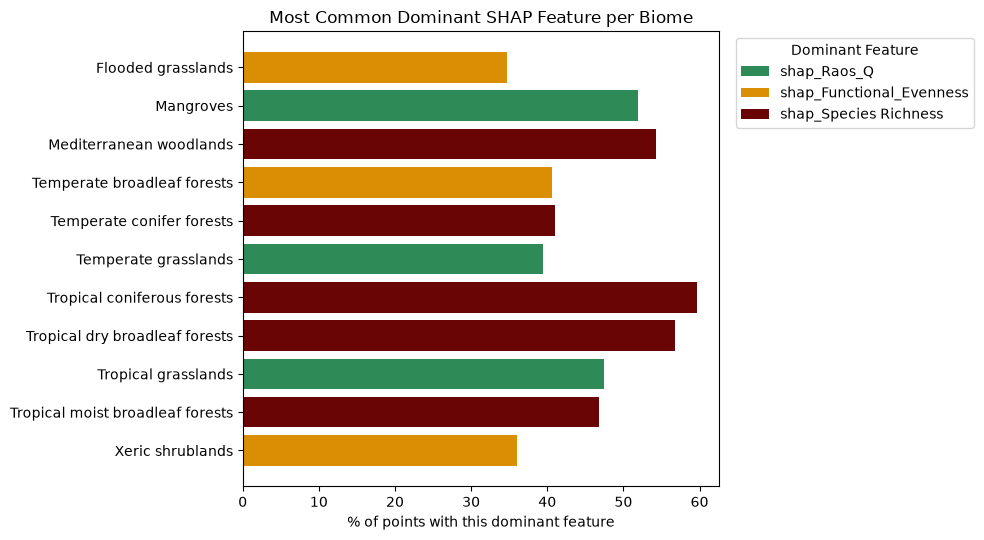

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Species Richness": "#6A0505",
}


# --- Find the dominant (mode) top_feature per biome ---
biome_dominant = (
    df2.groupby('biome')['top_feature']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'top_feature': 'dominant_feature'})
)

# Count how many points support that dominant feature, for context
biome_counts = df2.groupby(['biome', 'top_feature']).size().reset_index(name='count')
biome_totals = df2.groupby('biome').size().reset_index(name='total')

biome_dominant = biome_dominant.merge(
    biome_counts, left_on=['biome', 'dominant_feature'], right_on=['biome', 'top_feature']
).merge(biome_totals, on='biome')

biome_dominant['pct'] = biome_dominant['count'] / biome_dominant['total'] * 100

# print(biome_dominant[['biome', 'dominant_feature', 'count', 'total', 'pct']])

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, max(4, len(biome_dominant) * 0.5)))

colors = biome_dominant['dominant_feature'].map(color_map).fillna("#D3D3D3")

bars = ax.barh(biome_dominant['biome'], biome_dominant['pct'], color=colors)

ax.set_xlabel('% of points with this dominant feature')
ax.set_title('Most Common Dominant SHAP Feature per Biome')
ax.invert_yaxis()

# Add feature name as text label on each bar
# for bar, feat in zip(bars, biome_dominant['dominant_feature']):
#     ax.text(
#         bar.get_width() + 1,
#         bar.get_y() + bar.get_height() / 2,
#         feat,
#         va='center', fontsize=9
#     )

# Legend
legend_elements = [Patch(facecolor=color, label=feat) for feat, color in color_map.items()]
ax.legend(handles=legend_elements, title="Dominant Feature",
          bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

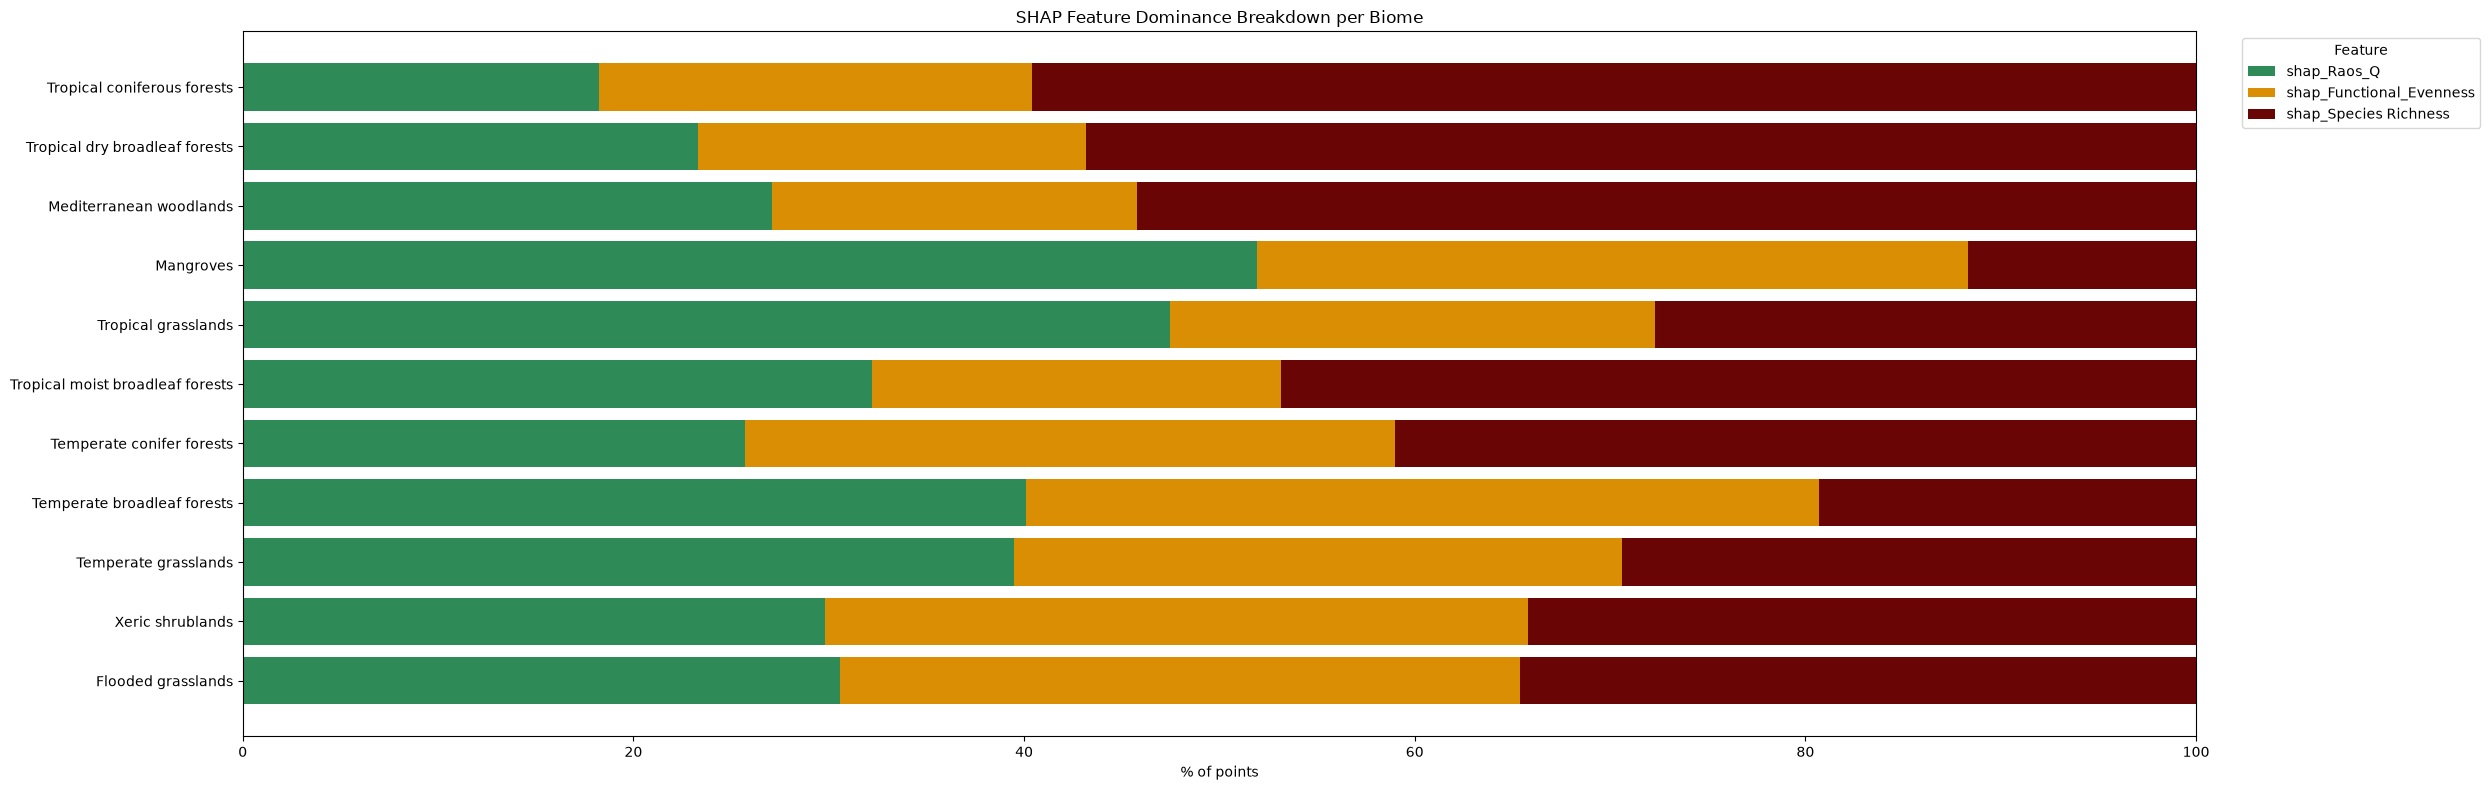

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}

# --- % of each feature within each biome ---
biome_feature_counts = (
    df2.groupby(['biome', 'top_feature'])
    .size()
    .reset_index(name='count')
)

biome_totals = df2.groupby('biome').size().reset_index(name='total')

biome_feature_counts = biome_feature_counts.merge(biome_totals, on='biome')
biome_feature_counts['pct'] = biome_feature_counts['count'] / biome_feature_counts['total'] * 100

# Pivot to wide format: rows = biome, columns = feature, values = pct
pivot = biome_feature_counts.pivot(index='biome', columns='top_feature', values='pct').fillna(0)

# Order columns consistently with color_map, keep only features present in data
features_ordered = [f for f in color_map.keys() if f in pivot.columns]
pivot = pivot[features_ordered]

# Optional: order biomes by their single most dominant feature's pct, descending
biome_order = pivot.max(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[biome_order]

# --- Plot stacked horizontal bars ---
fig, ax = plt.subplots(figsize=(25,8))

left = np.zeros(len(pivot))
for feat in features_ordered:
    color = color_map.get(feat, "#D3D3D3")
    ax.barh(pivot.index, pivot[feat], left=left, color=color, label=feat)
    left += pivot[feat].values

ax.set_xlabel('% of points')
ax.set_title('SHAP Feature Dominance Breakdown per Biome')
ax.set_xlim(0, 100)
ax.invert_yaxis()

legend_elements = [Patch(facecolor=color_map[f], label=f) for f in features_ordered]
ax.legend(handles=legend_elements, title="Feature",
          bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

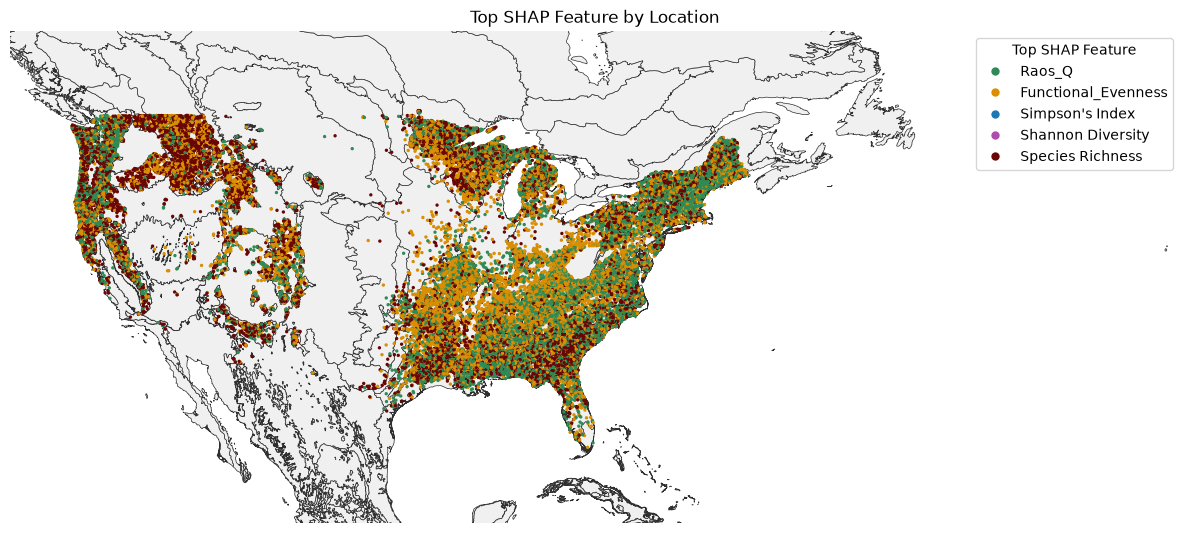

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}

# Convert to GeoDataFrame
top_feature_gdf = gpd.GeoDataFrame(
    top_feature_df,
    geometry=gpd.points_from_xy(top_feature_df.lon, top_feature_df.lat),
    crs="EPSG:4326"
)

# Map feature names to colours
top_feature_gdf["colour"] = top_feature_gdf["top_feature"].map(color_map)

# Load ecoregions
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")

fig, ax = plt.subplots(figsize=(12, 12))

# Ecoregion background
ecoregions.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#2E2E2E",
    linewidth=0.5
)

# Plot points using your colours
top_feature_gdf.plot(
    ax=ax,
    color=top_feature_gdf["colour"],
    markersize=2
)

# Custom legend
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=colour,
        markeredgecolor='none',
        markersize=6,
        label=feature.replace("shap_", "")
    )
    for feature, colour in color_map.items()
]

ax.legend(
    handles=legend_handles,
    title="Top SHAP Feature",
    loc="upper right",
    frameon=True
)

ax.set_title("Top SHAP Feature by Location")
ax.set_axis_off()

# Zoom to North America
ax.set_xlim(-130, -30)
ax.set_ylim(20, 55)

plt.tight_layout()
plt.show()

In [35]:
eco=pd.read_csv('data/lookup/PID_with_ecoregion.csv')
biome_df=fd_df[['PID', 'biome', 'transformed npp', 'lon', 'lat', 'WSCI']]


eco_df = pd.merge(df1, eco, on='PID', how='left')
eco = eco.merge(ecoregions, on='ECO_NAME', how='left')

biome_df = biome_df.merge(eco, on='PID', how='left')

shap_cols =  ['shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness',]

# Mean SHAP values per ecoregion
eco_shap_mean = eco_df.groupby("ECO_NAME")[shap_cols].mean()
eco_shap_mean["dominant_feature"] = eco_shap_mean.idxmax(axis=1)

# Count of plots (PIDs) per ecoregion
plot_counts = eco_df.groupby("ECO_NAME")["PID"].nunique()
eco_shap_mean["plot_count"] = plot_counts

# Filter to ecoregions with more than 10 plots
eco_shap_mean = eco_shap_mean[eco_shap_mean["plot_count"] > 100]

eco_df = eco_shap_mean.merge(ecoregions, left_index=True, right_on="ECO_NAME", how="left")

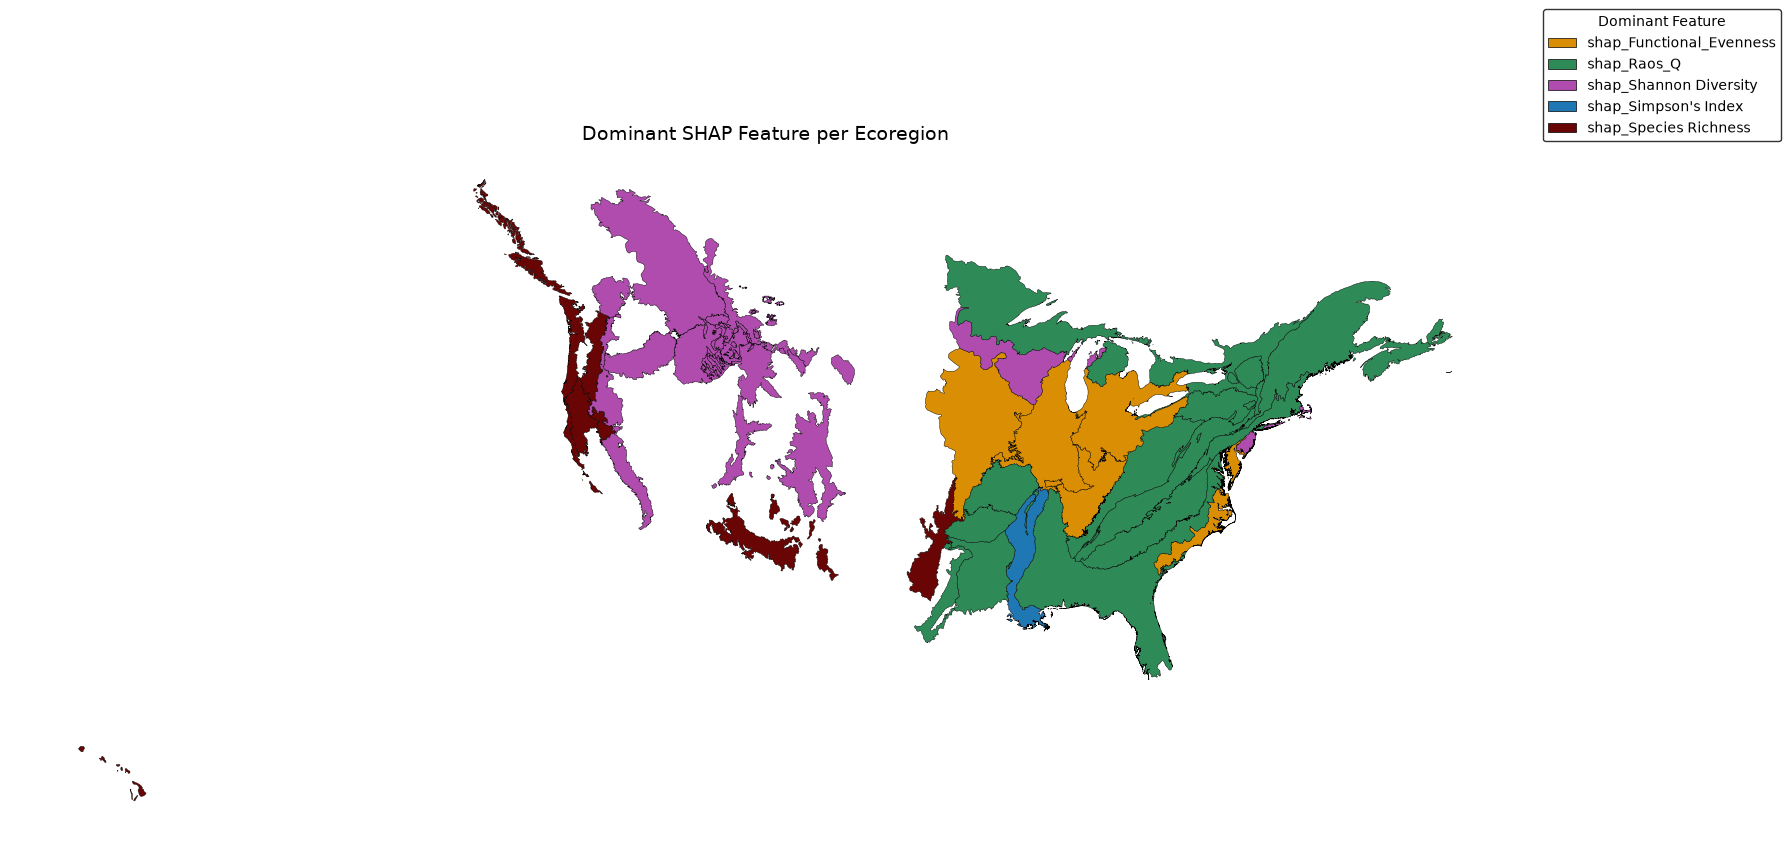

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd

eco_map = eco_df[['ECO_NAME', 'geometry', 'dominant_feature']].copy()
eco_map = gpd.GeoDataFrame(eco_map, geometry="geometry")

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Simpson's Index": "#1F77B4",
    "shap_Shannon Diversity": "#B04CAE",
    "shap_Species Richness": "#6A0505",
}


# Map colors directly to each row — no patch-matching needed
eco_map['color'] = eco_map['dominant_feature'].map(color_map)

# Reproject to a standard geographic CRS to fix scaling/connectivity artifacts
if eco_map.crs is None:
    eco_map = eco_map.set_crs("EPSG:4326")
else:
    eco_map = eco_map.to_crs("EPSG:4326")

# Optionally clip to valid lat/lon bounds to drop any corrupt geometries
from shapely.geometry import box
world_bounds = box(-180, -90, 180, 90)
eco_map['geometry'] = eco_map['geometry'].intersection(world_bounds)
eco_map = eco_map[~eco_map['geometry'].is_empty]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

eco_map.plot(
    color=eco_map['color'],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

legend_elements = [
    Patch(facecolor=color_map[cat], edgecolor='black', label=cat, linewidth=0.5)
    for cat in sorted(color_map.keys())
]
ax.legend(
    handles=legend_elements,
    title="Dominant Feature",
    bbox_to_anchor=(1.01, 1),
    loc='lower left',
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

ax.set_title("Dominant SHAP Feature per Ecoregion", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

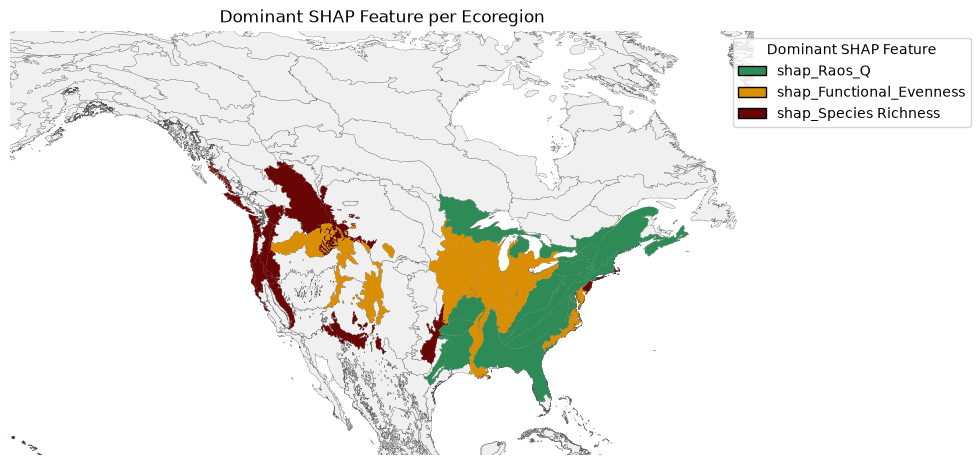

In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import box

# Load full ecoregion layer
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")

# GeoDataFrame containing only ecoregions with dominant features
eco_map = eco_df[['ECO_NAME', 'geometry', 'dominant_feature']].copy()
eco_map = gpd.GeoDataFrame(eco_map, geometry="geometry")

color_map = {
    "shap_Raos_Q": "#2E8B57",
    "shap_Functional_Evenness": "#D98E03",
    "shap_Species Richness": "#6A0505",
}

eco_map["color"] = eco_map["dominant_feature"].map(color_map)

# Ensure same CRS
if ecoregions.crs != eco_map.crs:
    eco_map = eco_map.to_crs(ecoregions.crs)

# Optional: clip invalid geometries
world = box(-180, -90, 180, 90)
ecoregions["geometry"] = ecoregions.geometry.intersection(world)
eco_map["geometry"] = eco_map.geometry.intersection(world)

ecoregions = ecoregions[~ecoregions.geometry.is_empty]
eco_map = eco_map[~eco_map.geometry.is_empty]

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Background: ALL ecoregions
ecoregions.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="#545454",
    linewidth=0.2,
    zorder=1
)

# Overlay coloured ecoregions
eco_map.plot(
    ax=ax,
    color=eco_map["color"],
    linewidth=0.2,
    zorder=2
)

# Legend
legend_elements = [
    Patch(facecolor=color_map[k], edgecolor="black", label=k)
    for k in color_map
]

ax.legend(
    handles=legend_elements,
    title="Dominant SHAP Feature",
    bbox_to_anchor=(1.3, 1),
    loc="upper right",
)

ax.set_title("Dominant SHAP Feature per Ecoregion")
ax.set_axis_off()

# North America extent
ax.set_xlim(-160, -50)
ax.set_ylim(20, 70)

plt.tight_layout()
plt.show()